In [18]:
import copy
import math
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.colors as colors
import matplotlib.pyplot as plt
from optim import SSBFGS, SSBroyden

In [19]:
class Net(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.depth = len(layers) - 1
        self.activation = nn.Tanh()

        # Build the network
        layer_list = []
        for i in range(self.depth - 1):
            layer_list.append(nn.Linear(layers[i], layers[i+1]))
            layer_list.append(self.activation)
        layer_list.append(nn.Linear(layers[-2], layers[-1]))

        self.net = nn.Sequential(*layer_list)

    def forward(self, x, y):
        X = torch.cat([x, y], dim=1)
        return self.net(X)

class HardCodeNet(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.depth = len(layers) - 1
        self.activation = nn.Tanh()

        # Build the network
        layer_list = []
        for i in range(self.depth - 1):
            layer_list.append(nn.Linear(layers[i], layers[i+1]))
            layer_list.append(self.activation)
        layer_list.append(nn.Linear(layers[-2], layers[-1]))

        self.net = nn.Sequential(*layer_list)

    def forward(self, x, y):
        X = torch.cat([x, y], dim=1)
        N_out = self.net(X)
        u_pred = (3 - 4*x**2 - 4*x*y**2 - y**4 - 2*y**2 + 4*x) * N_out
        return u_pred

Consider the Poisson equation on the irregular, non-convex domain $\Omega \subset \mathbb{R}^2$ defined by: $\Omega = \left\{ (x, y) \in \mathbb{R}^2 \;\middle|\; 4x^2 + 4xy^2 + y^4 + 2y^2 - 4x < 3 \right\}$

The boundary value problem with homogeneous Dirichlet boundary conditions is formulated as:
$$
\begin{cases}
    \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = -8x^2 - 12xy^2 - 24xy - 28x - 20y^3 - 8y^2 - 20y + 8 & \text{ in } \Omega \\
    u(x, y) = 0 & \text{ on } \partial\Omega
\end{cases}
$$

The exact analytical solution to this problem is given by the manufactured polynomial function:
$$u(x, y) = \left(3 + 4x - 4x^2 - 4xy^2 - 2y^2 - y^4\right) \cdot (x + y)$$

To sample boundary points or enforce boundary conditions, the domain boundary $\partial\Omega$ can be explicitly parameterized by the angular variable $\theta \in [0, 2\pi)$ via the transformation:
$$
\begin{cases}
    x(\theta) = \cos\theta + 0.5\cos^2\theta \\
    y(\theta) = \sin\theta
\end{cases}
$$

In [20]:
torch.manual_seed(42)
np.random.seed(42)

In [21]:
# --- Collocation points ---
N_f = 1000
x_interior = []
y_interior = []

x_min, x_max = -0.6, 1.6
y_min, y_max = -1.1, 1.1
while len(x_interior) < N_f:
    x_cand = np.random.uniform(x_min, x_max, N_f - len(x_interior))
    y_cand = np.random.uniform(y_min, y_max, N_f - len(y_interior))

    inside_mask = (4*x_cand**2 + 4*x_cand*y_cand**2 + y_cand**4 + 2*y_cand**2 - 4*x_cand) < 3.0

    x_interior.extend(x_cand[inside_mask])
    y_interior.extend(y_cand[inside_mask])

x_f = torch.tensor(x_interior[:N_f], dtype=torch.float32).reshape(-1, 1).requires_grad_(True)
y_f = torch.tensor(y_interior[:N_f], dtype=torch.float32).reshape(-1, 1).requires_grad_(True)
f = (-8*x_f**2 - 12*x_f*y_f**2 - 24*x_f*y_f - 28*x_f - 20*y_f**3 - 8*y_f**2 - 20*y_f + 8).detach()

# --- Boundary points ---
N_b = 200
theta_b = torch.rand(N_b, 1) * 2*math.pi
x_b = torch.cos(theta_b) + 0.5*torch.cos(theta_b)**2
y_b = torch.sin(theta_b)

# --- Exact solution at interior collocation points ---
u_exact_train = ((3 + 4*x_f - 4*x_f**2 - 4*x_f*y_f**2 - 2*y_f**2 - y_f**4)*(x_f + y_f)).detach()
l2_relative_error = {}
mse = {}
l_inf_error = {}

In [22]:
def compute_loss(net, name=""):
    # Wipe the input gradients inside the closure!
    if x_f.grad is not None: x_f.grad.zero_()
    if y_f.grad is not None: y_f.grad.zero_()

    # --- Compute the PDE residual ---
    u_f = net(x_f, y_f)
    u_x = torch.autograd.grad(u_f.sum(), x_f, create_graph=True)[0]
    u_y = torch.autograd.grad(u_f.sum(), y_f ,create_graph=True)[0]

    u_xx = torch.autograd.grad(u_x, x_f, torch.ones_like(u_x), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y_f, torch.ones_like(u_y), create_graph=True)[0]

    residual = u_xx + u_yy - f
    loss_pde = torch.mean(residual**2)

    # --- Compute the boundary loss ---
    if name == "Standard":
        u_b_pred = net(x_b, y_b)
        loss_bc = torch.mean(u_b_pred**2)
        loss_pde += loss_bc
    return loss_pde

def record_metrics(net, name):
    # Disable gradients just for metric calculation to save memory/time
    with torch.no_grad():
        u_f = net(x_f, y_f)
        diff = u_f - u_exact_train

        l2_relative_error[name].append((torch.norm(diff) / torch.norm(u_exact_train)).item())
        mse[name].append(torch.mean(diff ** 2).item())
        l_inf_error[name].append(torch.max(torch.abs(diff)).item())

        plateau_mse = False
        if len(mse[name]) > 100:
            window = mse[name][-100:]
            rel_spread = (max(window) - min(window)) / (min(window) + 1e-12)
            plateau_mse = rel_spread < 1e-4

        return plateau_mse

In [23]:
# --- Initialize the network ---
layers = [2, 50, 50, 50, 1]
adamNet = Net(layers)
adamOptimizer = optim.Adam(adamNet.parameters(), lr=1e-3)

l2_relative_error["Standard"] = []
mse["Standard"] = []
l_inf_error["Standard"] = []

# --- Training loop ---
adam_epochs = 5000
start = time.time()
for epoch in range(adam_epochs):
    adamOptimizer.zero_grad()
    loss = compute_loss(adamNet, "Standard")
    # --- Backpropagation ---
    loss.backward()
    adamOptimizer.step()

    # Record metrics exactly once per epoch
    plateau = record_metrics(adamNet, 'Standard')
    if plateau:
        break

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6e}")

print(f'Training completed in {time.time() - start:.2f} seconds')

Epoch 0, Loss: 7.727102e+02
Epoch 500, Loss: 5.050379e-01
Epoch 1000, Loss: 4.869980e-02
Epoch 1500, Loss: 2.092538e-02
Epoch 2000, Loss: 1.339341e-02
Epoch 2500, Loss: 9.441575e-03
Epoch 3000, Loss: 7.227584e-03
Epoch 3500, Loss: 6.005236e-03
Epoch 4000, Loss: 3.982536e-03
Epoch 4500, Loss: 7.385001e-02
Training completed in 50.24 seconds


In [24]:
hcAdamNet = HardCodeNet(layers)

l2_relative_error["HCAdam"] = []
mse["HCAdam"] = []
l_inf_error["HCAdam"] = []

# --- Stage 1: Adam Optimizer (Initialization) ---
print("Stage 1: Pre-training with Adam...")
hcAdamOptimizer = optim.Adam(hcAdamNet.parameters(), lr=1e-3)

start = time.time()
for epoch in range(2000): # Adam iterations
    hcAdamOptimizer.zero_grad()
    loss = compute_loss(hcAdamNet)
    loss.backward()
    hcAdamOptimizer.step()

    # Record metrics exactly once per epoch
    plateau = record_metrics(hcAdamNet, 'HCAdam')
    if plateau:
        break

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6e}")

adam_time = time.time() - start

Stage 1: Pre-training with Adam...
Epoch 0, Loss: 6.381755e+02
Epoch 500, Loss: 6.160720e-02
Epoch 1000, Loss: 2.621977e-02
Epoch 1500, Loss: 1.456553e-02


In [25]:
stdLBFGSNet = copy.deepcopy(hcAdamNet) # Experiment 2
l2_relative_error["std"] = l2_relative_error["HCAdam"][:]
mse["std"] = mse["HCAdam"][:]
l_inf_error["std"] = l_inf_error["HCAdam"][:]

sqrtLBFGSNet = copy.deepcopy(hcAdamNet) # Experiment 3
l2_relative_error["sqrt"] = l2_relative_error["HCAdam"][:]
mse["sqrt"] = mse["HCAdam"][:]
l_inf_error["sqrt"] = l_inf_error["HCAdam"][:]

logLBFGSNet = copy.deepcopy(hcAdamNet) # Experiment 4
l2_relative_error["log"] = l2_relative_error["HCAdam"][:]
mse["log"] = mse["HCAdam"][:]
l_inf_error["log"] = l_inf_error["HCAdam"][:]

sSBFGSNet = copy.deepcopy(hcAdamNet) # Experiment 5
l2_relative_error["ssbfgs"] = l2_relative_error["HCAdam"][:]
mse["ssbfgs"] = mse["HCAdam"][:]
l_inf_error["ssbfgs"] = l_inf_error["HCAdam"][:]

sSBroydenNet = copy.deepcopy(hcAdamNet) # Experiment 6
l2_relative_error["ssbroyden"] = l2_relative_error["HCAdam"][:]
mse["ssbroyden"] = mse["HCAdam"][:]
l_inf_error["ssbroyden"] = l_inf_error["HCAdam"][:]

In [26]:
# --- EXPERIMENT 1: Continue with Adam (No LBFGS) ---
print("Exp 1: Continuing Adam...")
start = time.time()
for epoch in range(3000):
    hcAdamOptimizer.zero_grad()
    loss = compute_loss(hcAdamNet)
    loss.backward()
    hcAdamOptimizer.step()

    # Record metrics exactly once per epoch
    plateau = record_metrics(hcAdamNet, 'HCAdam')
    if plateau:
        break

    if epoch % 500 == 0:
        print(f"Epoch {epoch},  Loss: {loss.item():.6e}")

print(f"Total time Adam: {adam_time + time.time() - start:.2f} seconds")

Exp 1: Continuing Adam...
Epoch 0,  Loss: 8.127916e-03
Epoch 500,  Loss: 4.403182e-03
Epoch 1000,  Loss: 2.432309e-03
Epoch 1500,  Loss: 1.497372e-03
Epoch 2000,  Loss: 1.036934e-03
Epoch 2500,  Loss: 7.880985e-04
Total time Adam: 57.65 seconds


In [27]:
# --- EXPERIMENT 2: Standard LBFGS (Minimize MSE) ---
print("Exp 2: Standard LBFGS (MSE)...")
stdOptimizer = optim.LBFGS(
    stdLBFGSNet.parameters(),
    lr=1.0,
    max_iter=1,
    max_eval=20,
    history_size=100,  # Large history ~ full BFGS
    tolerance_grad=1e-11,
    tolerance_change=1e-11,
    line_search_fn="strong_wolfe"
)

lbfgs_epochs = 3000

start = time.time()
for epoch in range(lbfgs_epochs):
    def closure_std():
        stdOptimizer.zero_grad()
        loss = compute_loss(stdLBFGSNet) # Standard Loss
        loss.backward()
        return loss

    # Take ONE step (the line search happens silently inside here)
    loss_val = stdOptimizer.step(closure_std)

    # Record metrics exactly once per successful step
    plateau = record_metrics(stdLBFGSNet, 'std')
    if plateau:
        break

    if epoch % 500 == 0:
        # current_loss = closure_std().item()
        print(f"L-BFGS Epoch {epoch}, Loss: {loss_val.item():.6e}")

lbfgs_time = adam_time + time.time() - start
print(f"Total time (Adam + LBFGS): {lbfgs_time:.2f} seconds")

Exp 2: Standard LBFGS (MSE)...
L-BFGS Epoch 0, Loss: 8.127916e-03
Total time (Adam + LBFGS): 33.33 seconds


In [28]:
# --- EXPERIMENT 3: Modified LBFGS (Minimize Sqrt(MSE)) ---
print("Exp 3: Modified LBFGS (J_1/2)...")
sqrtOptimizer = optim.LBFGS(
    sqrtLBFGSNet.parameters(),
    lr=1.0,
    max_iter=1,
    max_eval=20,
    history_size=100,  # Large history ~ full BFGS
    tolerance_grad=1e-11,
    tolerance_change=1e-11,
    line_search_fn="strong_wolfe"
)

start = time.time()
for epoch in range(lbfgs_epochs):
    def closure_sqrt():
        sqrtOptimizer.zero_grad()
        loss_mse = compute_loss(sqrtLBFGSNet)
        loss_sqrt = torch.sqrt(loss_mse)
        loss_sqrt.backward()
        return loss_sqrt

    # Take ONE step (the line search happens silently inside here)
    loss_val = sqrtOptimizer.step(closure_sqrt)

    # Record metrics exactly once per successful step
    plateau = record_metrics(sqrtLBFGSNet, 'sqrt')
    if plateau:
        break

    if epoch % 500 == 0:
        # current_loss = closure_sqrt().item()
        print(f"L-BFGS Epoch {epoch}, Loss: {math.pow(loss_val.item(), 2):.6e}")

sqrt_time = adam_time + time.time() - start
print(f"Total time (Adam + sqrt LBFGS): {sqrt_time:.2f} seconds")

Exp 3: Modified LBFGS (J_1/2)...
L-BFGS Epoch 0, Loss: 8.127916e-03
Total time (Adam + sqrt LBFGS): 34.01 seconds


In [29]:
# --- EXPERIMENT 4: Modified LBFGS (Minimize log(MSE)) ---
print("Exp 4: Modified LBFGS (log(J))...")
logOptimizer = optim.LBFGS(
    logLBFGSNet.parameters(),
    lr=1.0,
    max_iter=1,
    max_eval=20,
    history_size=100,  # Large history ~ full BFGS
    tolerance_grad=1e-11,
    tolerance_change=1e-11,
    line_search_fn="strong_wolfe"
)

start = time.time()
for epoch in range(lbfgs_epochs):
    def closure_log():
        logOptimizer.zero_grad()
        loss_mse = compute_loss(logLBFGSNet)
        loss_log = torch.log(loss_mse)
        loss_log.backward()
        return loss_log

    # Take ONE step (the line search happens silently inside here)
    loss_val = logOptimizer.step(closure_log)

    # Record metrics exactly once per successful step
    plateau = record_metrics(logLBFGSNet, 'log')
    if plateau:
        break

    if epoch % 500 == 0:
        # current_loss = closure_log().item()
        print(f"L-BFGS Epoch {epoch}, Loss: {math.exp(loss_val.item()):.6e}")

log_time = adam_time + time.time() - start
print(f"Total time (Adam + log LBFGS): {log_time:.2f} seconds")

Exp 4: Modified LBFGS (log(J))...
L-BFGS Epoch 0, Loss: 8.127915e-03
Total time (Adam + log LBFGS): 35.76 seconds


In [30]:
# --- EXPERIMENT 5: Modified BFGS (SSBFGS) ---
print("Exp 5: SSBFGS...")
ssbfgsOptimizer = SSBFGS(
    sSBFGSNet.parameters(),
    lr=1.0,
    max_iter=1,
    max_eval=20,
    history_size=100,  # Large history ~ full BFGS
    tolerance_grad=1e-11,
    tolerance_change=1e-11,
    line_search_fn="strong_wolfe"
)

start = time.time()
for epoch in range(lbfgs_epochs):
    def closure_ssbfgs():
        ssbfgsOptimizer.zero_grad()
        loss = compute_loss(sSBFGSNet)
        loss.backward()
        return loss

    # Take ONE step (the line search happens silently inside here)
    loss_val = ssbfgsOptimizer.step(closure_ssbfgs)

    # Record metrics exactly once per successful step
    plateau = record_metrics(sSBFGSNet, 'ssbfgs')
    if plateau:
        break

    if epoch % 500 == 0:
        # current_loss = closure_ssbfgs().item()
        print(f"SSBFGS Epoch {epoch}, Loss: {loss_val.item():.6e}")

ssbfgs_time = adam_time + time.time() - start
print(f"Total time (Adam + SSBFGS): {ssbfgs_time:.2f} seconds")

Exp 5: SSBFGS...
SSBFGS Epoch 0, Loss: 8.124387e-03
SSBFGS Epoch 500, Loss: 1.591275e-10
SSBFGS Epoch 1000, Loss: 1.037500e-10
Total time (Adam + SSBFGS): 379.39 seconds


In [31]:
# --- EXPERIMENT 6: Modified Broyden (SSBroyden) ---
print("Exp 6: SSBroyden...")
ssbroydenOptimizer = SSBroyden(
    sSBroydenNet.parameters(),
    lr=1.0,
    max_iter=1,
    max_eval=20,
    history_size=100,  # Large history ~ full BFGS
    tolerance_grad=1e-11,
    tolerance_change=1e-11,
    line_search_fn="strong_wolfe"
)

start = time.time()
for epoch in range(lbfgs_epochs):
    def closure_ssbroyden():
        ssbroydenOptimizer.zero_grad()
        loss = compute_loss(sSBroydenNet)
        loss.backward()
        return loss

    # Take ONE step (the line search happens silently inside here)
    loss_val = ssbroydenOptimizer.step(closure_ssbroyden)

    # Record metrics exactly once per successful step
    plateau = record_metrics(sSBroydenNet, 'ssbroyden')
    if plateau:
        break

    if epoch % 500 == 0:
        # current_loss = closure_ssbroyden().item()
        print(f"SSBroyden Epoch {epoch}, Loss: {loss_val.item():.6e}")

ssbroyden_time = adam_time + time.time() - start
print(f"Total time (Adam + SSBroyden): {ssbroyden_time:.2f} seconds")

Exp 6: SSBroyden...
SSBroyden Epoch 0, Loss: 8.124387e-03
SSBroyden Epoch 500, Loss: 1.601013e-10
SSBroyden Epoch 1000, Loss: 8.124466e-11
SSBroyden Epoch 1500, Loss: 7.956846e-11
Total time (Adam + SSBroyden): 536.73 seconds


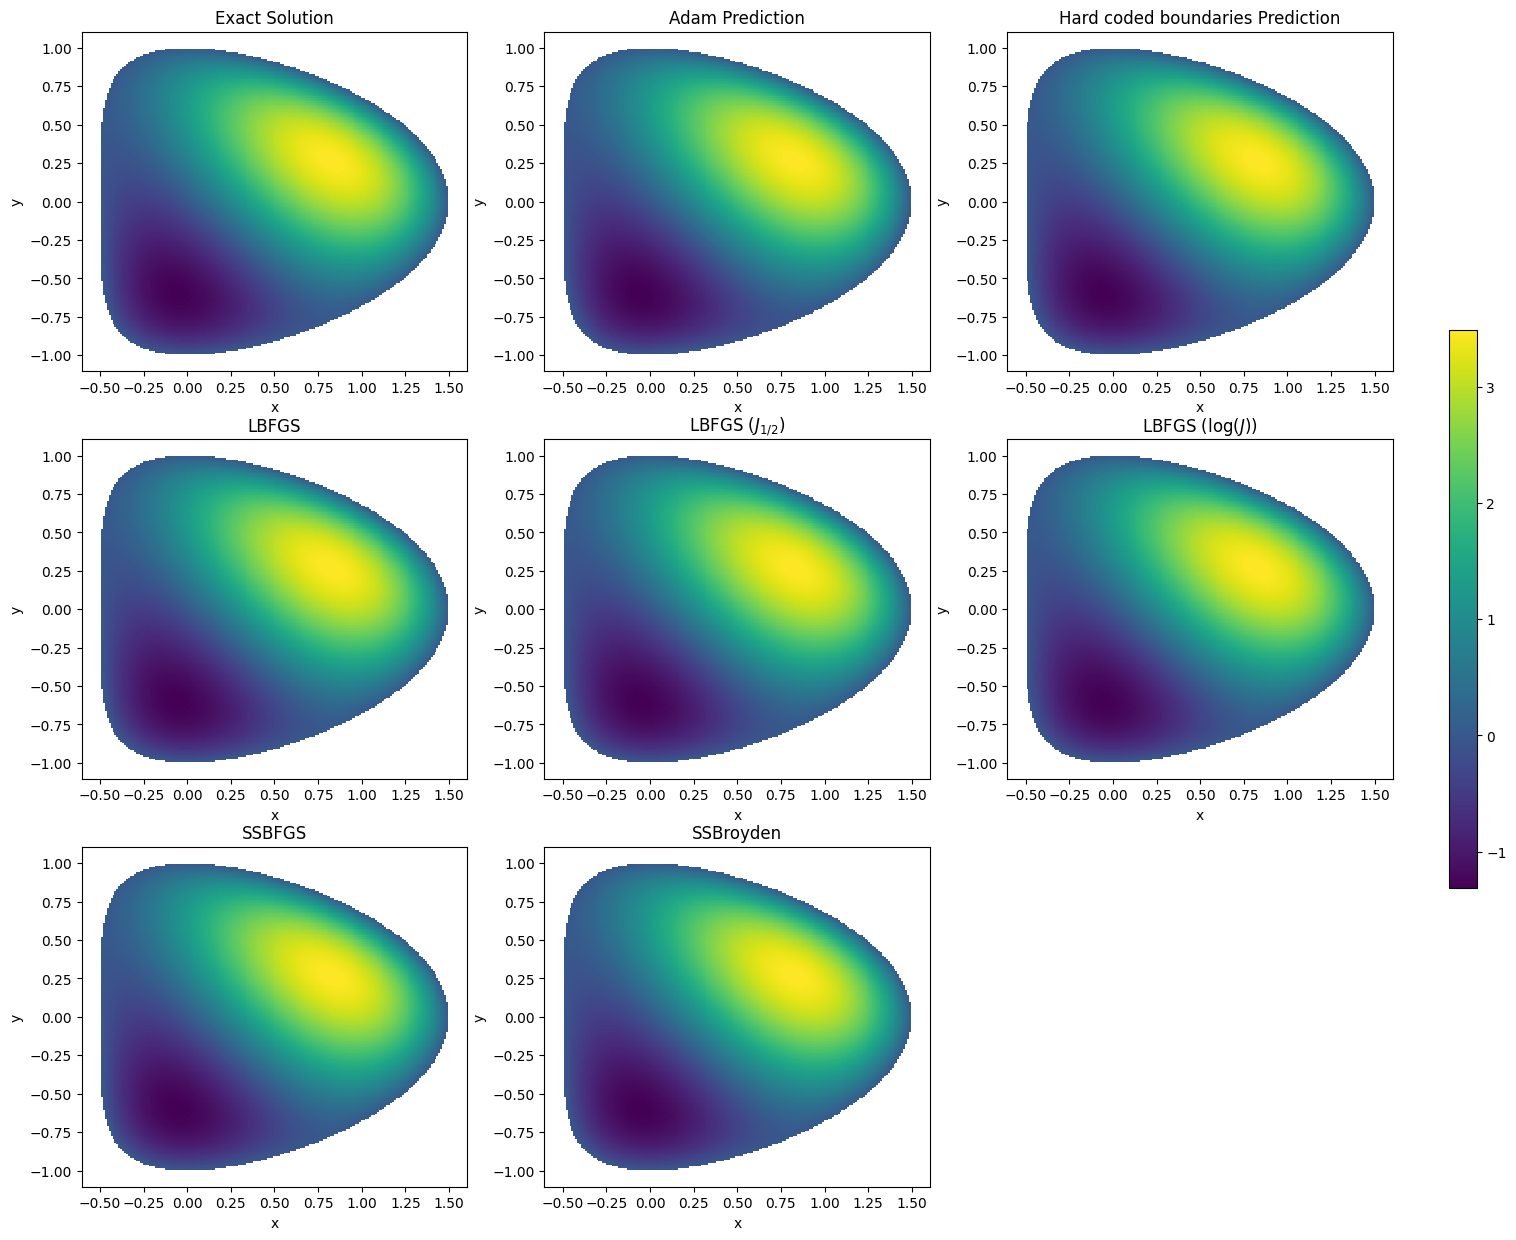

In [50]:
# --- Evaluation ---
x = torch.linspace(-0.6, 1.6, 200)
y = torch.linspace(-1.1, 1.1, 200)
X, Y = torch.meshgrid(x, y, indexing='ij')

X_flat = X.reshape(-1, 1)
Y_flat = Y.reshape(-1, 1)

with torch.no_grad():
    u_pred = adamNet(X_flat, Y_flat).reshape(200,200).numpy()
    u_pred_hc = hcAdamNet(X_flat, Y_flat).reshape(200,200).numpy()
    u_pred_std = stdLBFGSNet(X_flat, Y_flat).reshape(200, 200).numpy()
    u_pred_sqrt = sqrtLBFGSNet(X_flat, Y_flat).reshape(200, 200).numpy()
    u_pred_log = logLBFGSNet(X_flat, Y_flat).reshape(200, 200).numpy()
    u_pred_ssbfgs = sSBFGSNet(X_flat, Y_flat).reshape(200, 200).numpy()
    u_pred_ssbroyden = sSBroydenNet(X_flat, Y_flat).reshape(200, 200).numpy()
    u_exact_vis = ((3.0 + 4.0*X_flat - 4.0*X_flat**2 - 4.0*X_flat*Y_flat**2 - 2.0*Y_flat**2 - Y_flat**4)*(X_flat + Y_flat)).reshape(200, 200).numpy()

# --- Boundary mask condition ---
X_np = X.numpy()
Y_np = Y.numpy()
inside_domain = (4*X_np**2 + 4*X_np*Y_np**2 + Y_np**4 + 2*Y_np**2 - 4*X_np) < 3.0

u_pred[~inside_domain] = np.nan
u_pred_hc[~inside_domain] = np.nan
u_pred_std[~inside_domain] = np.nan
u_pred_sqrt[~inside_domain] = np.nan
u_pred_log[~inside_domain] = np.nan
u_pred_ssbfgs[~inside_domain] = np.nan
u_pred_ssbroyden[~inside_domain] = np.nan
u_exact_vis[~inside_domain] = np.nan


all_data = [u_exact_vis, u_pred, u_pred_hc, u_pred_std, u_pred_sqrt, u_pred_log, u_pred_ssbfgs, u_pred_ssbroyden]
vmin = np.min([np.nanmin(d) for d in all_data])
vmax = np.max([np.nanmax(d) for d in all_data])

fig = plt.figure(figsize=(18,15))

# Exact solution
plt.subplot(3,3,1)
im = plt.pcolormesh(X_np, Y_np, u_exact_vis, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title('Exact Solution')
plt.xlabel('x')
plt.ylabel('y')

# PINN prediction
plt.subplot(3,3,2)
plt.pcolormesh(X_np, Y_np, u_pred, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title('Adam Prediction')
plt.xlabel('x')
plt.ylabel('y')

# Hard coded boundaries prediction
plt.subplot(3,3,3)
plt.pcolormesh(X_np, Y_np, u_pred_hc, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title('Hard coded boundaries Prediction')
plt.xlabel('x')
plt.ylabel('y')

# Standard LBFGS prediction
plt.subplot(3,3,4)
plt.pcolormesh(X_np, Y_np, u_pred_std, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title('LBFGS')
plt.xlabel('x')
plt.ylabel('y')

# Sqrt LBFGS prediction
plt.subplot(3,3,5)
plt.pcolormesh(X_np, Y_np, u_pred_sqrt, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title(r'LBFGS ($J_{1/2}$)')
plt.xlabel('x')
plt.ylabel('y')

# Log LBFGS prediction
plt.subplot(3,3,6)
plt.pcolormesh(X_np, Y_np, u_pred_log, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title(r'LBFGS ($\log(J)$)')
plt.xlabel('x')
plt.ylabel('y')

# Sqrt SSBFGS prediction
plt.subplot(3,3,7)
plt.pcolormesh(X_np, Y_np, u_pred_ssbfgs, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title(r'SSBFGS')
plt.xlabel('x')
plt.ylabel('y')

# Log SSBroyden prediction
plt.subplot(3,3,8)
plt.pcolormesh(X_np, Y_np, u_pred_ssbroyden, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title(r'SSBroyden')
plt.xlabel('x')
plt.ylabel('y')

fig.colorbar(im, ax=fig.get_axes(), orientation='vertical', fraction=0.02, pad=0.04)

plt.show()

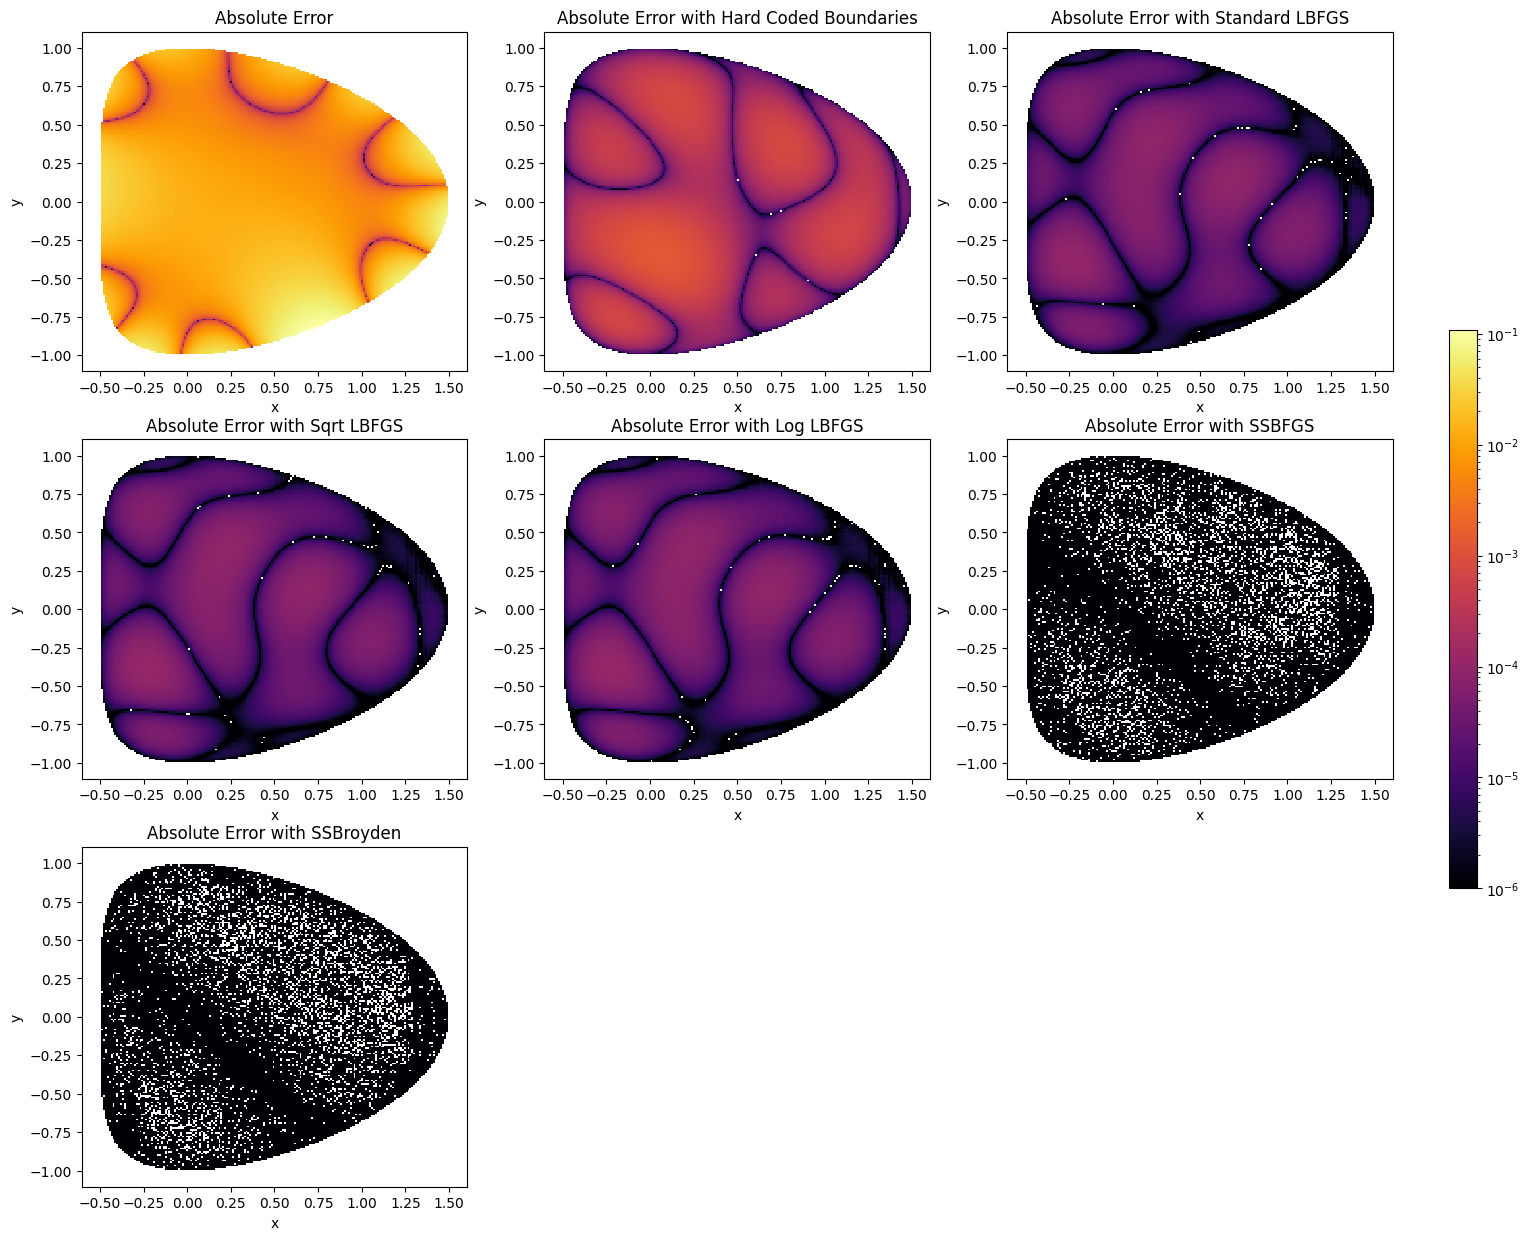

In [51]:
err_adam = np.abs(u_pred - u_exact_vis)
err_hc = np.abs(u_pred_hc - u_exact_vis)
err_std  = np.abs(u_pred_std - u_exact_vis)
err_sqrt = np.abs(u_pred_sqrt - u_exact_vis)
err_log  = np.abs(u_pred_log - u_exact_vis)
err_ssbfgs = np.abs(u_pred_ssbfgs - u_exact_vis)
err_ssbroyden  = np.abs(u_pred_ssbroyden - u_exact_vis)

all_errors = [err_adam, err_hc, err_std, err_sqrt, err_log, err_ssbfgs, err_ssbroyden]
vmin_log = 1e-6
vmax = np.max([np.nanmax(e) for e in all_errors])

fig = plt.figure(figsize=(18,15))

plt.subplot(3,3,1)
im = plt.pcolormesh(X_np, Y_np, err_adam, shading='auto', cmap='inferno', norm=colors.LogNorm(vmin=vmin_log, vmax=vmax))
plt.title('Absolute Error')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(3,3,2)
plt.pcolormesh(X_np, Y_np, err_hc, shading='auto', cmap='inferno', norm=colors.LogNorm(vmin=vmin_log, vmax=vmax))
plt.title('Absolute Error with Hard Coded Boundaries')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(3,3,3)
plt.pcolormesh(X_np, Y_np, err_std, shading='auto', cmap='inferno', norm=colors.LogNorm(vmin=vmin_log, vmax=vmax))
plt.title('Absolute Error with Standard LBFGS')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(3,3,4)
plt.pcolormesh(X_np, Y_np, err_sqrt, shading='auto', cmap='inferno', norm=colors.LogNorm(vmin=vmin_log, vmax=vmax))
plt.title('Absolute Error with Sqrt LBFGS')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(3,3,5)
plt.pcolormesh(X_np, Y_np, err_log, shading='auto', cmap='inferno', norm=colors.LogNorm(vmin=vmin_log, vmax=vmax))
plt.title('Absolute Error with Log LBFGS')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(3,3,6)
plt.pcolormesh(X_np, Y_np, err_ssbfgs, shading='auto', cmap='inferno', norm=colors.LogNorm(vmin=vmin_log, vmax=vmax))
plt.title('Absolute Error with SSBFGS')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(3,3,7)
plt.pcolormesh(X_np, Y_np, err_ssbroyden, shading='auto', cmap='inferno', norm=colors.LogNorm(vmin=vmin_log, vmax=vmax))
plt.title('Absolute Error with SSBroyden')
plt.xlabel('x')
plt.ylabel('y')

fig.colorbar(im, ax=fig.get_axes(), orientation='vertical', fraction=0.02, pad=0.04)

plt.show()

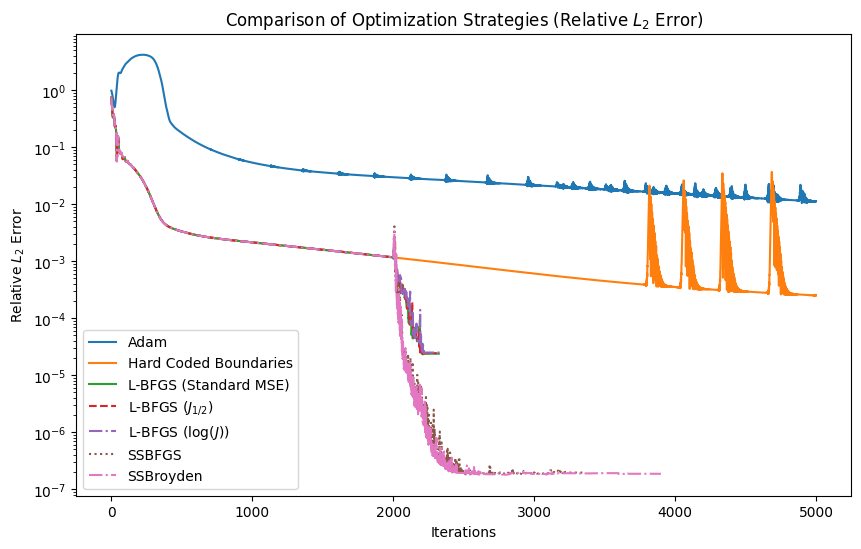

In [35]:
plt.figure(figsize=(10, 6))

plt.semilogy(l2_relative_error["Standard"], label='Adam') # Exp 1: More Adam
plt.semilogy(l2_relative_error["HCAdam"], label='Hard Coded Boundaries') # Exp 1: More Adam
plt.semilogy(l2_relative_error["std"], label='L-BFGS (Standard MSE)') # Exp 2: Standard LBFGS
plt.semilogy(l2_relative_error["sqrt"], label=r'L-BFGS ($J_{1/2}$)', linestyle='--')
plt.semilogy(l2_relative_error["log"], label=r'L-BFGS ($\log(J)$)', linestyle='-.')
plt.semilogy(l2_relative_error["ssbfgs"], label='SSBFGS', linestyle=':')
plt.semilogy(l2_relative_error["ssbroyden"], label='SSBroyden', linestyle='-.')

plt.xlabel('Iterations')
plt.ylabel(r'Relative $L_2$ Error')
plt.title(r'Comparison of Optimization Strategies (Relative $L_2$ Error)')
plt.legend()
plt.show()

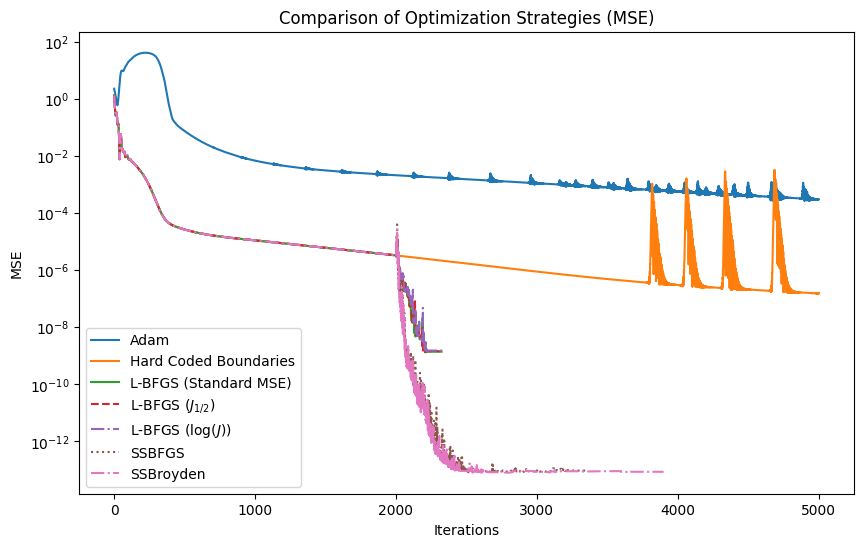

In [37]:
plt.figure(figsize=(10, 6))

plt.semilogy(mse["Standard"], label='Adam') # Exp 1: More Adam
plt.semilogy(mse["HCAdam"], label='Hard Coded Boundaries') # Exp 1: More Adam
plt.semilogy(mse["std"], label='L-BFGS (Standard MSE)') # Exp 2: Standard LBFGS
plt.semilogy(mse["sqrt"], label=r'L-BFGS ($J_{1/2}$)', linestyle='--')
plt.semilogy(mse["log"], label=r'L-BFGS ($\log(J)$)', linestyle='-.')
plt.semilogy(mse["ssbfgs"], label='SSBFGS', linestyle=':')
plt.semilogy(mse["ssbroyden"], label='SSBroyden', linestyle='-.')

plt.xlabel('Iterations')
plt.ylabel('MSE')
plt.title('Comparison of Optimization Strategies (MSE)')
plt.legend()
plt.show()

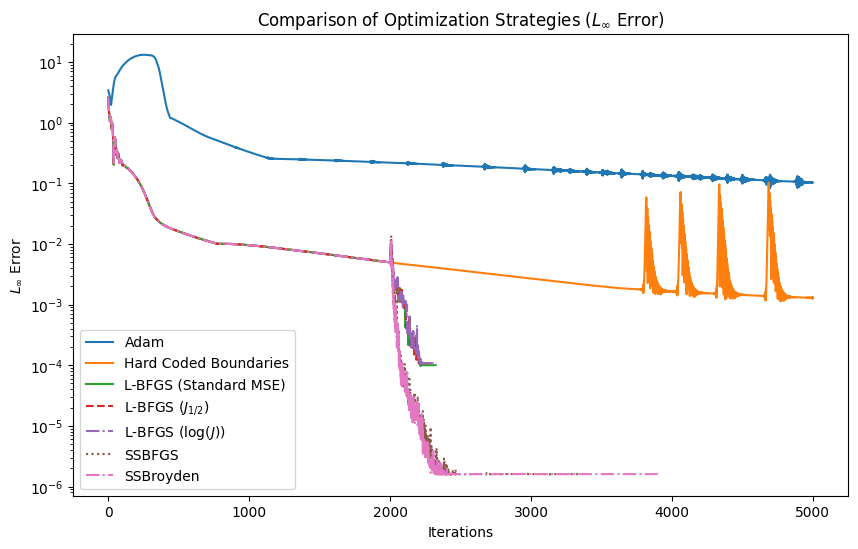

In [38]:
# --- PLOTTING ---
plt.figure(figsize=(10, 6))

plt.semilogy(l_inf_error["Standard"], label='Adam') # Exp 1: More Adam
plt.semilogy(l_inf_error["HCAdam"], label='Hard Coded Boundaries') # Exp 1: More Adam
plt.semilogy(l_inf_error["std"], label='L-BFGS (Standard MSE)') # Exp 2: Standard LBFGS
plt.semilogy(l_inf_error["sqrt"], label=r'L-BFGS ($J_{1/2}$)', linestyle='--')
plt.semilogy(l_inf_error["log"], label=r'L-BFGS ($\log(J)$)', linestyle='-.')
plt.semilogy(l_inf_error["ssbfgs"], label='SSBFGS', linestyle=':')
plt.semilogy(l_inf_error["ssbroyden"], label='SSBroyden', linestyle='-.')

plt.xlabel('Iterations')
plt.ylabel(r'$L_{\infty}$ Error')
plt.title('Comparison of Optimization Strategies ($L_{\infty}$ Error)')
plt.legend()
plt.show()


In [39]:
mse_adam = np.mean(err_adam ** 2)
mse_hc = np.mean(err_hc ** 2)
mse_std = np.mean(err_std ** 2)
mse_sqrt = np.mean(err_sqrt ** 2)
mse_log = np.mean(err_log ** 2)
mse_ssbfgs = np.mean(err_ssbfgs ** 2)
mse_ssbroyden = np.mean(err_ssbroyden ** 2)


print("MSE:")
print(f"Adam: {mse_adam:.6e}")
print(f"HC Boundaries: {mse_hc:.6e}")
print(f"LBFGS: {mse_std:.6e}")
print(f"LBFGS J_1/2: {mse_sqrt:.6e}")
print(f"LBFGS log(J): {mse_log:.6e}")
print(f"SSBFGS: {mse_ssbfgs:.6e}")
print(f"SSBroyden: {mse_ssbroyden:.6e}")

MSE:
Adam: nan
HC Boundaries: nan
LBFGS: nan
LBFGS J_1/2: nan
LBFGS log(J): nan
SSBFGS: nan
SSBroyden: nan
